In [68]:
import pandas as pd
import matplotlib.pyplot as plt

In [69]:
df = pd.read_csv('../data/MICRODADOS.csv', sep=';', encoding='latin-1', low_memory=False)
print(f'Total de registros: {len(df):,}')
print(f'Colunas: {list(df.columns)}')
df.head()

Total de registros: 5,188,660
Colunas: ['DataNotificacao', 'DataCadastro', 'DataDiagnostico', 'DataColeta_RT_PCR', 'DataColetaTesteRapido', 'DataColetaSorologia', 'DataColetaSorologiaIGG', 'DataEncerramento', 'DataObito', 'Classificacao', 'Evolucao', 'CriterioConfirmacao', 'StatusNotificacao', 'Municipio', 'Bairro', 'FaixaEtaria', 'IdadeNaDataNotificacao', 'Sexo', 'RacaCor', 'Escolaridade', 'Gestante', 'Febre', 'DificuldadeRespiratoria', 'Tosse', 'Coriza', 'DorGarganta', 'Diarreia', 'Cefaleia', 'ComorbidadePulmao', 'ComorbidadeCardio', 'ComorbidadeRenal', 'ComorbidadeDiabetes', 'ComorbidadeTabagismo', 'ComorbidadeObesidade', 'FicouInternado', 'ViagemBrasil', 'ViagemInternacional', 'ProfissionalSaude', 'PossuiDeficiencia', 'MoradorDeRua', 'ResultadoRT_PCR', 'ResultadoTesteRapido', 'ResultadoSorologia', 'ResultadoSorologia_IGG', 'TipoTesteRapido']


,DataNotificacao,DataCadastro,DataDiagnostico,DataColeta_RT_PCR,DataColetaTesteRapido,DataColetaSorologia,DataColetaSorologiaIGG,DataEncerramento,DataObito,Classificacao,...,ViagemBrasil,ViagemInternacional,ProfissionalSaude,PossuiDeficiencia,MoradorDeRua,ResultadoRT_PCR,ResultadoTesteRapido,ResultadoSorologia,ResultadoSorologia_IGG,TipoTesteRapido
0,2026-03-21,2026-03-21,Mar 18 2026 12:00AM,NaN,NaN,NaN,NaN,NaN,NaN,Suspeito,...,Não,Não,Não,Não,Não,Não Informado,Não Informado,Não Informado,Não Informado,Não Informado
1,2026-03-21,2026-03-21,Mar 17 2026 12:00AM,NaN,2026-03-21,NaN,NaN,NaN,NaN,Suspeito,...,Não,Não,Não,Não,Não,Não Informado,Não Informado,Não Informado,Não Informado,Ignorado
2,2026-03-21,2026-03-21,Mar 17 2026 12:00AM,2026-03-21,NaN,NaN,NaN,NaN,NaN,Suspeito,...,Não,Não,Não,Não,Não,Não Informado,Não Informado,Não Informado,Não Informado,Não Informado
3,2026-03-21,2026-03-21,Mar 21 2026 12:00AM,2026-03-21,NaN,NaN,NaN,NaN,NaN,Suspeito,...,Não,Não,Não,Não,Não,Não Informado,Não Informado,Não Informado,Não Informado,Não Informado
4,2026-03-21,2026-03-21,Mar 10 2026 12:00AM,2026-03-21,2026-03-21,NaN,NaN,NaN,NaN,Suspeito,...,Não,Não,Não,Não,Não,Não Informado,Negativo,Não Informado,Não Informado,Teste rápido Antígeno


### Exercício 1 - Visão Geral do Dataset

**Enunciado:**
Exiba: 
(a) o número total de registros e colunas, 
(b) os tipos de dados de cada coluna com `dtypes`, 
(c) a quantidade e percentual de valores nulos por coluna (mostrando apenas as que têm nulos). 

Use `shape`, `dtypes` e `isnull().sum()`.

In [70]:
import pandas as pd

# (a) Número total de registros e colunas
print("(a) Dimensões do Dataset")
print(f"Número de registros (linhas): {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}\n")

# (b) Tipos de dados de cada coluna
print("(b) Tipos de dados das colunas:")
display(df.dtypes)

print()
print("")

# (c) Quantidade e percentual de valores nulos por coluna (apenas as que têm nulos)
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
perc_nulos = (nulos / df.shape[0]) * 100

nulos_df = pd.DataFrame({
    'Quantidade Nulos': nulos,
    'Percentual (%)': perc_nulos
})

print("(c) Quantidade e percentual de valores nulos por coluna:")
display(nulos_df.sort_values(by='Quantidade Nulos', ascending=False))

(a) Dimensões do Dataset
Número de registros (linhas): 5188660
Número de colunas: 45

(b) Tipos de dados das colunas:


DataNotificacao            str
DataCadastro               str
DataDiagnostico            str
DataColeta_RT_PCR          str
DataColetaTesteRapido      str
DataColetaSorologia        str
DataColetaSorologiaIGG     str
DataEncerramento           str
DataObito                  str
Classificacao              str
Evolucao                   str
CriterioConfirmacao        str
StatusNotificacao          str
Municipio                  str
Bairro                     str
FaixaEtaria                str
IdadeNaDataNotificacao     str
Sexo                       str
RacaCor                    str
Escolaridade               str
Gestante                   str
Febre                      str
DificuldadeRespiratoria    str
Tosse                      str
Coriza                     str
DorGarganta                str
Diarreia                   str
Cefaleia                   str
ComorbidadePulmao          str
ComorbidadeCardio          str
ComorbidadeRenal           str
ComorbidadeDiabetes        str
Comorbid



(c) Quantidade e percentual de valores nulos por coluna:


,Quantidade Nulos,Percentual (%)
DataObito,5165264,99.549094
DataColetaSorologia,5088593,98.071429
DataColetaSorologiaIGG,5041910,97.171717
DataColeta_RT_PCR,3575120,68.902568
DataColetaTesteRapido,1937672,37.344363
DataEncerramento,225582,4.347596
Bairro,44827,0.863942


### Exercício 2 - Distribuição por Classificação

**Enunciado:**
Utilizando a coluna `Classificacao`, calcule a frequência absoluta e percentual de cada categoria (Confirmados, Descartados, Suspeito, Síndrome Gripal não Especificada). Gere um gráfico de barras horizontal com os resultados.

,Frequência Absoluta,Percentual (%)
Classificacao,,
Descartados,3252400,62.682851
Confirmados,1398240,26.947998
Suspeito,392925,7.572764
Síndrome Gripal não Especificada,145095,2.796387


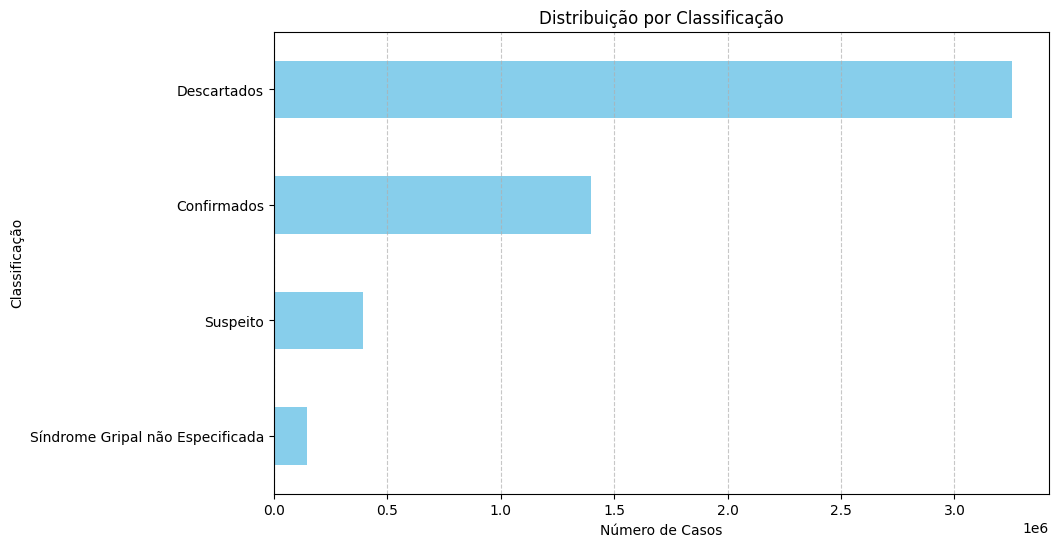

In [73]:
freq_abs = df['Classificacao'].value_counts()
freq_perc = df['Classificacao'].value_counts(normalize=True) * 100
df_classificacao = pd.DataFrame({'Frequência Absoluta': freq_abs, 'Percentual (%)': freq_perc})
display(df_classificacao)

plt.figure(figsize=(10, 6))
freq_abs.sort_values().plot(kind='barh', color='skyblue')
plt.title('Distribuição por Classificação')
plt.xlabel('Número de Casos')
plt.ylabel('Classificação')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Exercício 3 - Top 10 Municípios com Mais Notificações

**Enunciado:**
Identifique os 10 municípios com mais notificações no dataset. Gere um gráfico de barras mostrando o ranking. Escreva em Markdown qual município lidera e quantos registros possui.

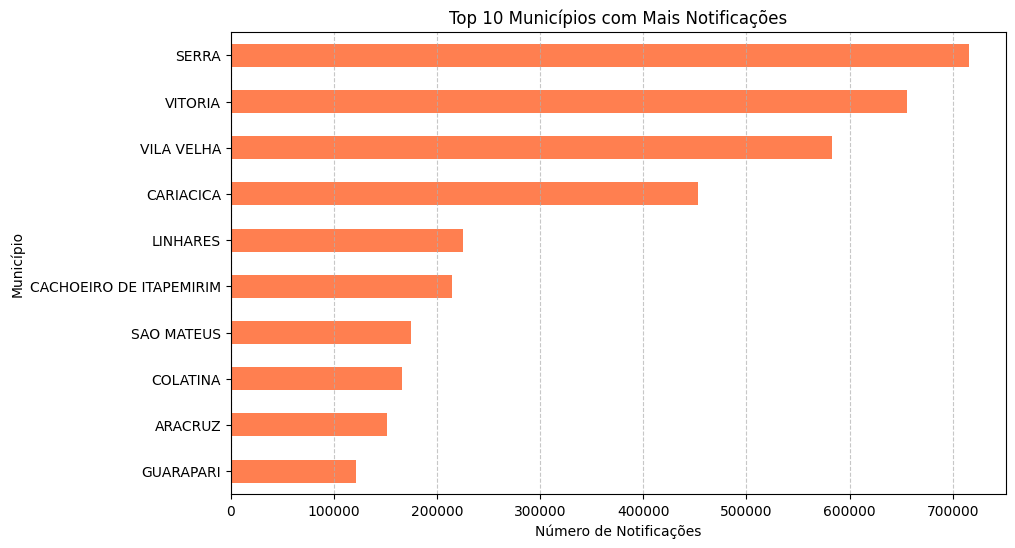

**Resposta:** O município que lidera em notificações é **SERRA**, com **715,867** registros.

In [61]:
from IPython.display import Markdown
top_10_mun = df['Municipio'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_10_mun.sort_values().plot(kind='barh', color='coral')
plt.title('Top 10 Municípios com Mais Notificações')
plt.xlabel('Número de Notificações')
plt.ylabel('Município')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

lider = top_10_mun.index[0]
registros = top_10_mun.values[0]
display(Markdown(f"**Resposta:** O município que lidera em notificações é **{lider}**, com **{registros:,}** registros."))

### Exercício 4 - Distribuição por Sexo

**Enunciado:**
Calcule a distribuição de notificações por `Sexo` (F, M, I). Gere um gráfico de pizza (pie chart) com percentuais. Interprete em Markdown: qual sexo concentra mais notificações?

Sexo
F    2924668
M    2263007
I        985
Name: count, dtype: int64

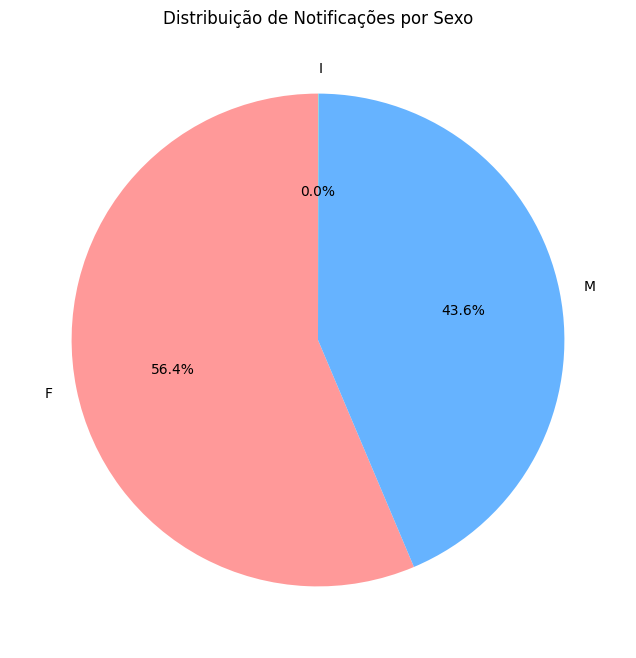

**Resposta:** O sexo que concentra mais notificações é o **F**.

In [62]:
dist_sexo = df['Sexo'].value_counts()
display(dist_sexo)

plt.figure(figsize=(8, 8))
dist_sexo.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribuição de Notificações por Sexo')
plt.ylabel('')
plt.show()

lider_sexo = dist_sexo.index[0]
display(Markdown(f"**Resposta:** O sexo que concentra mais notificações é o **{lider_sexo}**."))

### Exercício 5 - Casos por Faixa Etária

**Enunciado:**
Usando a coluna `FaixaEtaria`, gere um gráfico de barras mostrando o número de notificações por faixa etária. Ordene da menor para a maior faixa. Qual faixa concentra o maior volume?

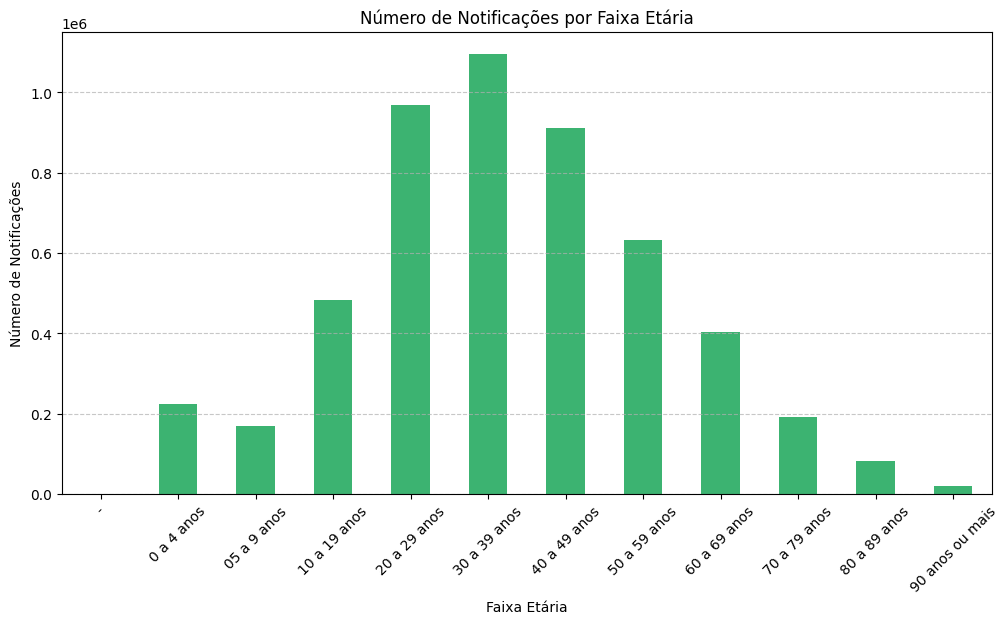

**Resposta:** A faixa etária que concentra o maior volume de notificações é: **30 a 39 anos**.

In [63]:
casos_faixa = df['FaixaEtaria'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
casos_faixa.plot(kind='bar', color='mediumseagreen')
plt.title('Número de Notificações por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Notificações')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

faixa_max = df['FaixaEtaria'].value_counts().index[0]
display(Markdown(f"**Resposta:** A faixa etária que concentra o maior volume de notificações é: **{faixa_max}**."))

### Exercício 6 - Taxa de Letalidade

**Enunciado:**
Filtre apenas os casos Confirmados (`Classificacao == 'Confirmados'`). Calcule quantos evoluíram para Óbito pelo COVID-19, Óbito por outras causas, Cura e Ignorado. Calcule a taxa de letalidade: (óbitos COVID / total de confirmados) × 100. Exiba os resultados numéricos e a taxa.

In [51]:
df_confirmados = df[df['Classificacao'] == 'Confirmados']
evolucao_confirmados = df_confirmados['Evolucao'].value_counts()

print("Evolução dos casos Confirmados:")
display(evolucao_confirmados)

total_confirmados = len(df_confirmados)
obitos_covid = evolucao_confirmados.get('Óbito pelo COVID-19', 0)

if total_confirmados > 0:
    taxa_letalidade = (obitos_covid / total_confirmados) * 100
else:
    taxa_letalidade = 0

print()
print()

print(f"Total de Confirmados: {total_confirmados:,}")
print(f"Óbitos pelo COVID-19: {obitos_covid:,}")
print(f"Taxa de Letalidade: {taxa_letalidade:.2f}%")

Evolução dos casos Confirmados:


Evolucao
Cura                       1354687
-                            20590
Óbito pelo COVID-19          15286
Ignorado                      7123
Óbito por outras causas        554
Name: count, dtype: int64



Total de Confirmados: 1,398,240
Óbitos pelo COVID-19: 15,286
Taxa de Letalidade: 1.09%


### Exercício 7 - Sintomas mais Frequentes

**Enunciado:**
As colunas de sintomas são: `Febre`, `DificuldadeRespiratoria`, `Tosse`, `Coriza`, `DorGarganta`, `Diarreia` e `Cefaleia`. Para cada uma, conte quantos registros têm valor "Sim". Gere um gráfico de barras horizontal ordenado do mais ao menos frequente.

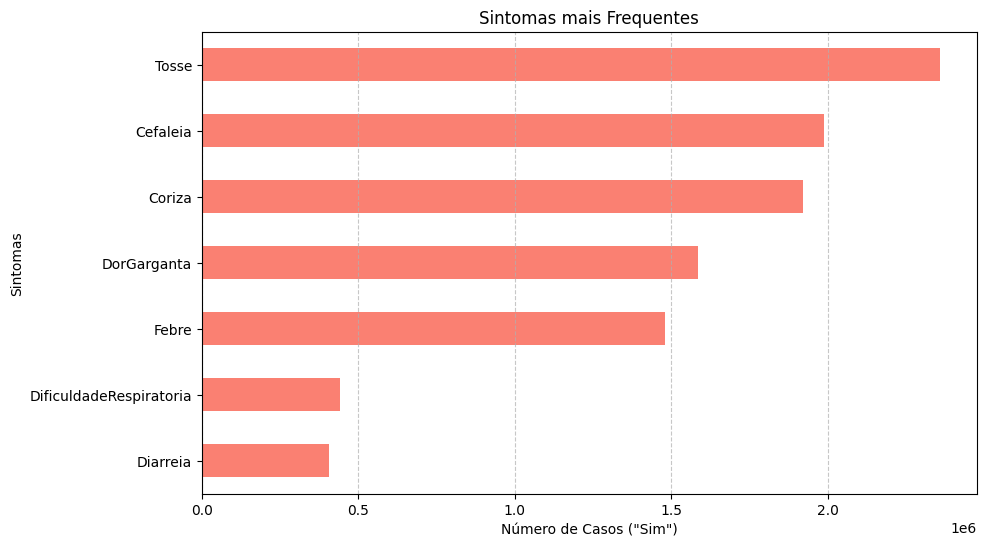

,Quantidade
Tosse,2359353
Cefaleia,1988206
Coriza,1922666
DorGarganta,1586337
Febre,1481316
DificuldadeRespiratoria,442438
Diarreia,407155


In [64]:
sintomas = ['Febre', 'DificuldadeRespiratoria', 'Tosse', 'Coriza', 'DorGarganta', 'Diarreia', 'Cefaleia']
contagem_sintomas = {s: (df[s] == 'Sim').sum() for s in sintomas if s in df.columns}
sintomas_series = pd.Series(contagem_sintomas).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sintomas_series.plot(kind='barh', color='salmon')
plt.title('Sintomas mais Frequentes')
plt.xlabel('Número de Casos ("Sim")')
plt.ylabel('Sintomas')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(pd.DataFrame(sintomas_series.sort_values(ascending=False), columns=['Quantidade']))

### Exercício 8 - Comorbidades nos Óbitos por COVID

**Enunciado:**
Filtre os registros com `Evolucao == 'Óbito pelo COVID-19'`. Para as colunas `ComorbidadePulmao`, `ComorbidadeCardio`, `ComorbidadeRenal`, `ComorbidadeDiabetes`, `ComorbidadeTabagismo` e `ComorbidadeObesidade`, conte quantos óbitos tinham cada comorbidade ("Sim"). Gere um gráfico de barras e interprete em Markdown: qual comorbidade está mais presente nos óbitos?

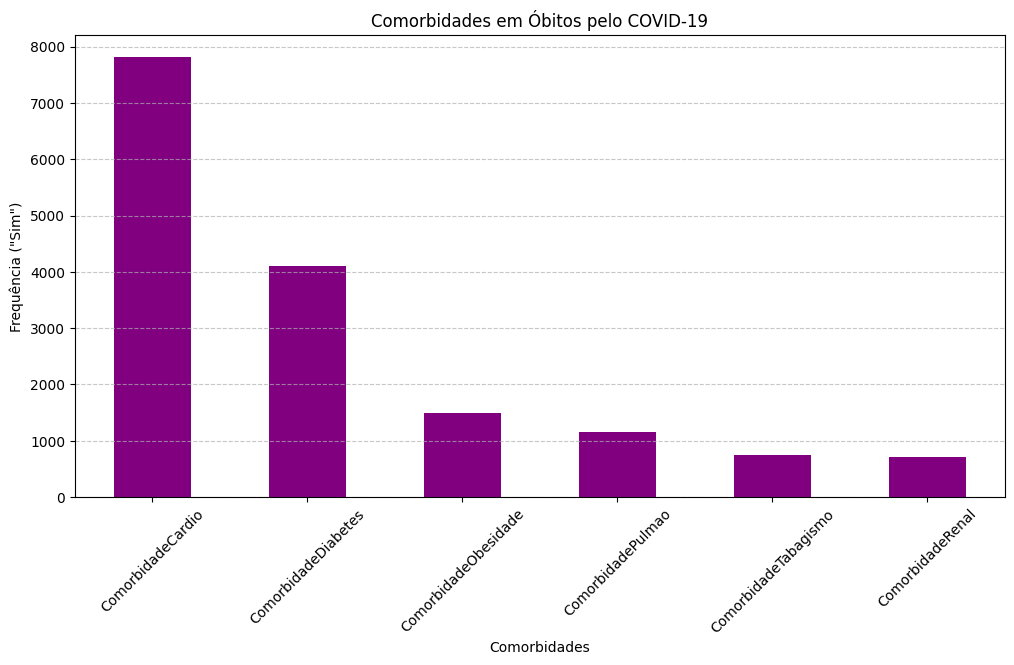

**Resposta:** A comorbidade mais presente nos óbitos é: **ComorbidadeCardio**.

In [65]:
obitos_covid = df[df['Evolucao'] == 'Óbito pelo COVID-19']
comorbidades = ['ComorbidadePulmao', 'ComorbidadeCardio', 'ComorbidadeRenal', 'ComorbidadeDiabetes', 'ComorbidadeTabagismo', 'ComorbidadeObesidade']

contagem_comorb = {c: (obitos_covid[c] == 'Sim').sum() for c in comorbidades if c in obitos_covid.columns}
comorb_series = pd.Series(contagem_comorb).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
comorb_series.plot(kind='bar', color='purple')
plt.title('Comorbidades em Óbitos pelo COVID-19')
plt.xlabel('Comorbidades')
plt.ylabel('Frequência ("Sim")')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

comorb_max = comorb_series.index[0] if not comorb_series.empty else "Nenhuma"
display(Markdown(f"**Resposta:** A comorbidade mais presente nos óbitos é: **{comorb_max}**."))

### Exercício 9 - Evolução Temporal das Notificações

**Enunciado:**
Converta `DataNotificacao` para datetime com `pd.to_datetime(...)`. Crie uma coluna `AnoMes` com `.dt.to_period('M')`. Agrupe por `AnoMes`, conte e gere um gráfico de linha. Identifique em Markdown os períodos de pico (ondas).

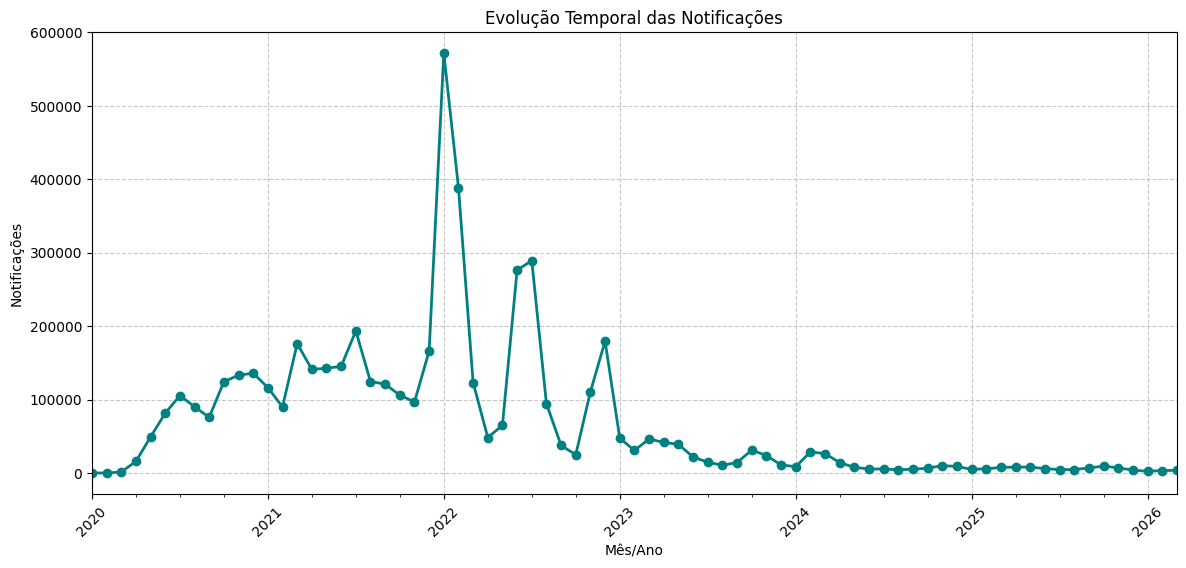

**Resposta:** Os meses com maiores picos (ondas) foram: **2022-01, 2022-02, 2022-07**.

In [66]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

df['DataNotificacao'] = pd.to_datetime(df['DataNotificacao'], errors='coerce')
df['AnoMes'] = df['DataNotificacao'].dt.to_period('M')
evolucao_temporal = df['AnoMes'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
evolucao_temporal.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Evolução Temporal das Notificações')
plt.xlabel('Mês/Ano')
plt.ylabel('Notificações')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

picos = evolucao_temporal.nlargest(3).index.astype(str).tolist()
resposta = f"Os meses com maiores picos (ondas) foram: **{', '.join(picos)}**." if picos else "Picos não identificados."
display(Markdown(f"**Resposta:** {resposta}"))

### Exercício 10 - Tabela Cruzada (Pivot Table)

**Enunciado:**
Crie uma tabela cruzada com `pd.crosstab` entre os 5 municípios com mais casos confirmados e a coluna `Evolucao`. Exiba a tabela. Calcule a taxa de letalidade por município e identifique qual dos 5 tem a maior taxa.

In [67]:
df_confirmados = df[df['Classificacao'] == 'Confirmados']
top5_mun = df_confirmados['Municipio'].value_counts().head(5).index
df_top5_conf = df_confirmados[df_confirmados['Municipio'].isin(top5_mun)]

tabela_cruzada = pd.crosstab(df_top5_conf['Municipio'], df_top5_conf['Evolucao'])
print("Tabela Cruzada:")
display(tabela_cruzada)

col_obito = 'Óbito pelo COVID-19'
if col_obito not in tabela_cruzada.columns:
    tabela_cruzada[col_obito] = 0

tabela_cruzada['Total'] = tabela_cruzada.sum(axis=1)
tabela_cruzada['Taxa Letalidade (%)'] = (tabela_cruzada[col_obito] / tabela_cruzada['Total']) * 100

print()
print("Taxa de Letalidade por Município:")
display(tabela_cruzada[['Taxa Letalidade (%)']].sort_values(by='Taxa Letalidade (%)', ascending=False))

maior_taxa_mun = tabela_cruzada['Taxa Letalidade (%)'].idxmax()
maior_taxa_val = tabela_cruzada['Taxa Letalidade (%)'].max()

from IPython.display import Markdown
display(Markdown(f"**Resposta:** O município com a maior taxa de letalidade dentre os 5 principais é **{maior_taxa_mun}** (taxa de **{maior_taxa_val:.2f}%**)."))

Tabela Cruzada:


Evolucao,-,Cura,Ignorado,Óbito pelo COVID-19,Óbito por outras causas
Municipio,,,,,
CARIACICA,7350,95603,1708,1644,30
LINHARES,1,65625,4,523,6
SERRA,90,156870,66,1820,61
VILA VELHA,11,155429,48,2082,66
VITORIA,42,160486,76,1493,29



Taxa de Letalidade por Município:


Evolucao,Taxa Letalidade (%)
Municipio,
CARIACICA,1.546057
VILA VELHA,1.320764
SERRA,1.145324
VITORIA,0.920889
LINHARES,0.790520


**Resposta:** O município com a maior taxa de letalidade dentre os 5 principais é **CARIACICA** (taxa de **1.55%**).